## Praktikum HDBSCAN pada Iris Dataset

In [1]:
# Import pustaka yang dibutuhkan
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import hdbscan

# Memuat dataset Iris dari sklearn.datasets
iris = load_iris()
X = iris.data
y_true = iris.target

# Melakukan standardisasi dan reduksi dimensi dengan PCA agar bisa divisualisasikan dalam 2D
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

### Definisi Fungsi Visualisasi

In [2]:
# Definisi Fungsi Visualisasi
def plot(X, labels, probabilities=None, parameters=None, ground_truth=False, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    labels = labels if labels is not None else np.ones(X.shape[0])
    probabilities = probabilities if probabilities is not None else np.ones(X.shape[0])
    unique_labels = set(labels)
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    proba_map = {idx: probabilities[idx] for idx in range(len(labels))}
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = [0, 0, 0, 1]  # warna hitam untuk noise
        class_index = (labels == k).nonzero()[0]
        for ci in class_index:
            ax.plot(
                X[ci, 0],
                X[ci, 1],
                "x" if k == -1 else "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=4 if k == -1 else 1 + 5 * proba_map[ci],
            )
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    preamble = "True" if ground_truth else "Estimated"
    title = f"{preamble} number of clusters: {n_clusters_}"
    if parameters is not None:
        parameters_str = ", ".join(f"{k}={v}" for k, v in parameters.items())
        title += f" | {parameters_str}"
    ax.set_title(title)
    plt.tight_layout()

### Penerapan HDBSCAN dan Evaluasi Hasil Cluster

Jumlah cluster yang terbentuk: 2
Banyaknya noise: 2


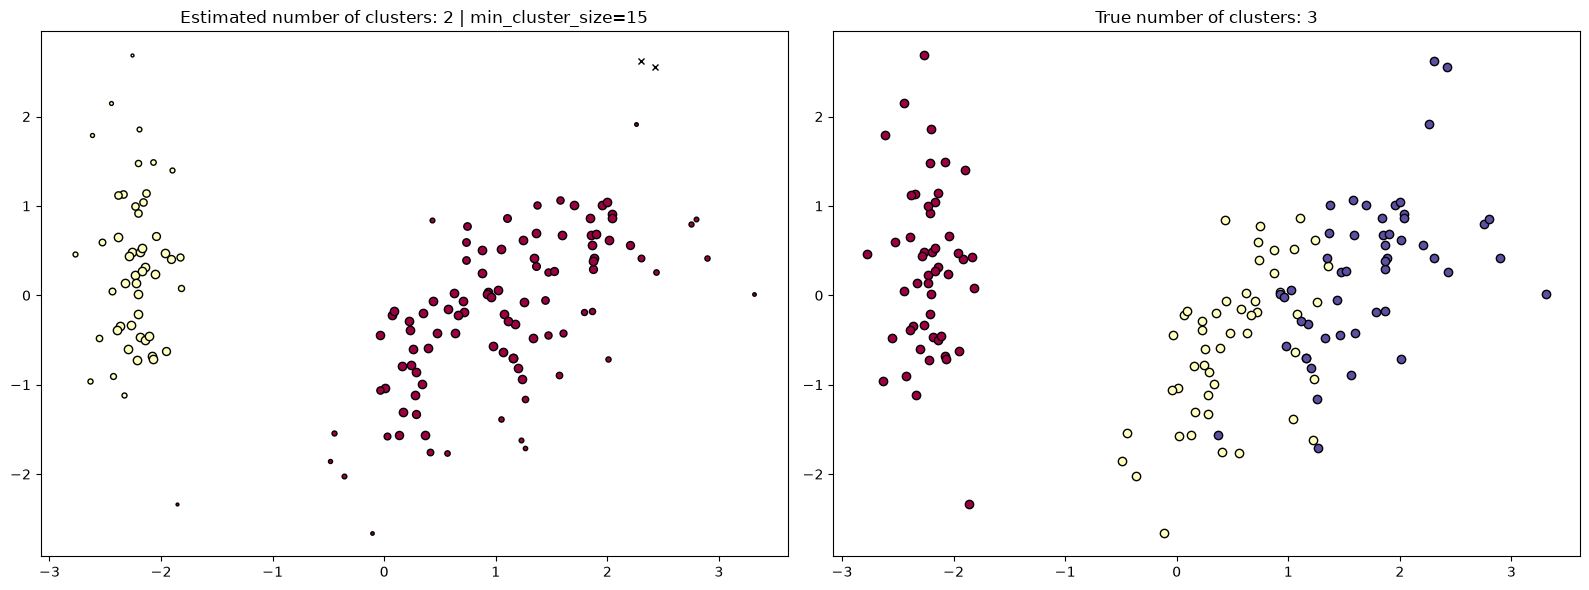

In [3]:
# Inisialisasi dan fitting model HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5)
clusterer.fit(X_reduced)

labels = clusterer.labels_
probabilities = clusterer.probabilities_

# Menghitung jumlah cluster dan banyaknya noise
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Jumlah cluster yang terbentuk: {n_clusters_}")
print(f"Banyaknya noise: {n_noise_}")

# Visualisasi perbandingan antara hasil estimasi HDBSCAN dan Ground Truth (Label Asli)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot hasil klasterisasi HDBSCAN
plot(X_reduced, labels, probabilities=probabilities, parameters={"min_cluster_size": 15}, ground_truth=False, ax=axes[0])

# Plot label asli dataset Iris
plot(X_reduced, y_true, ground_truth=True, ax=axes[1])

plt.show()

### Evaluasi Kuantitatif Hasil HDBSCAN terhadap Ground Truth

In [4]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import pandas as pd

# Menghitung metrik evaluasi (ARI dan NMI) terhadap label asli (y_true)
ari = adjusted_rand_score(y_true, labels)
nmi = normalized_mutual_info_score(y_true, labels)

print(f"Adjusted Rand Index (ARI) : {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")

# Membuat tabel silang (Cross-tabulation) antara Ground Truth dan Cluster HDBSCAN
# Catatan: Label -1 pada HDBSCAN merepresentasikan noise
df_eval = pd.DataFrame({
    'Ground_Truth (0=Setosa, 1=Versicolor, 2=Virginica)': y_true, 
    'HDBSCAN_Cluster (-1=Noise)': labels
})

crosstab = pd.crosstab(df_eval['Ground_Truth (0=Setosa, 1=Versicolor, 2=Virginica)'], 
                       df_eval['HDBSCAN_Cluster (-1=Noise)'])
print("\nTabel Distribusi Cluster vs Ground Truth:")
print(crosstab)

Adjusted Rand Index (ARI) : 0.5394
Normalized Mutual Info (NMI): 0.6778

Tabel Distribusi Cluster vs Ground Truth:
HDBSCAN_Cluster (-1=Noise)                          -1   0   1
Ground_Truth (0=Setosa, 1=Versicolor, 2=Virginica)            
0                                                    0   1  49
1                                                    0  50   0
2                                                    2  48   0
